In [1]:
# 重新划分时间段
import pandas as pd
df_fixed_effect = pd.read_csv('添加confirmed后的固定效应.csv',encoding = 'utf-8-sig')

- 根据每日新增的情况，将时间段划分为7个
- 0 2020-01-23前 未出现疫情
- 1 2020-04-22前 出现到爆发
- 2 2020-11-09：疫情得到控制   
- 3 2021-05-17：疫情常态化     
- 4 2022-08-04：疫情得到控制     
- 5 2022-12-06：疫情复发
- 6 2022-12-07后 疫情放开

In [2]:
# 对时间段进行划分
def period_segment(string1):
    if string1<'2020-01-23':
        period = 0
    elif string1<'2020-04-22':
        period = 1
    elif string1<'2020-11-09':
        period = 2
    elif string1<'2021-05-17':
        period = 3
    elif string1<'2022-08-04':
        period = 4
    elif string1<'2022-12-06':
        period = 5  
    else:
        period = 6      
    return period

df_fixed_effect['period']=df_fixed_effect['comment_day'].apply(period_segment)
df_fixed_effect

,Unnamed: 0,comment_day,scence_id,scence_name,sentiment_score,scence_id.1,city_new,high_temperature,holiday,outbreak,outbreak_timeDistance,period,Month,level,confirmed
0,0,2019-06-01,1267,三亚市南山大小洞天旅游区,35.725343,1267,三亚,33.0,1,0,236,0,6,0,0.0
1,1,2019-06-01,1363,乌鲁木齐市天山大峡谷景区,95.828390,1363,乌鲁木齐,29.0,1,0,236,0,6,0,0.0
2,2,2019-06-01,1239,佛山市西樵山景区,50.854552,1239,佛山,30.0,1,0,236,0,6,0,0.0
3,3,2019-06-01,1110,六安市万佛湖景区,78.599554,1110,六安,31.0,1,0,236,0,6,0,0.0
4,4,2019-06-01,1116,六安市天堂寨旅游景区,8.476657,1116,六安,31.0,1,0,236,0,6,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87949,88394,2022-11-28,1317,昆明市昆明世博园景区,12.635818,1317,昆明,23.0,0,1,0,5,11,4,3624.0
87950,88395,2022-11-28,1313,毕节市百里杜鹃景区,37.496600,1313,毕节,23.0,0,1,0,5,11,4,3624.0
87951,88396,2022-11-28,1282,酉阳桃花源旅游景区,87.084818,1282,重庆,19.0,0,1,0,5,11,4,3624.0
87952,88397,2022-11-28,1221,长沙市岳麓山·橘子洲旅游区,90.190923,1221,长沙,21.0,0,1,0,5,11,4,3624.0


# 一、论文复现

## 疫情前后的情感分析-方差分析

In [3]:
# 方差分析
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

model = ols('sentiment_score ~C(outbreak)', data =  df_fixed_effect).fit()
anova_table = anova_lm(model, type = 2)
pd.DataFrame(anova_table)
# p值为1.618530e-10，是小于0.05的，说明前后差别显著

,df,sum_sq,mean_sq,F,PR(>F)
C(outbreak),1.0,1.701069e+04,17010.686983,20.548088,0.000006
Residual,87952.0,7.281086e+07,827.847678,NaN,NaN


<AxesSubplot:xlabel='outbreak', ylabel='sentiment_score'>

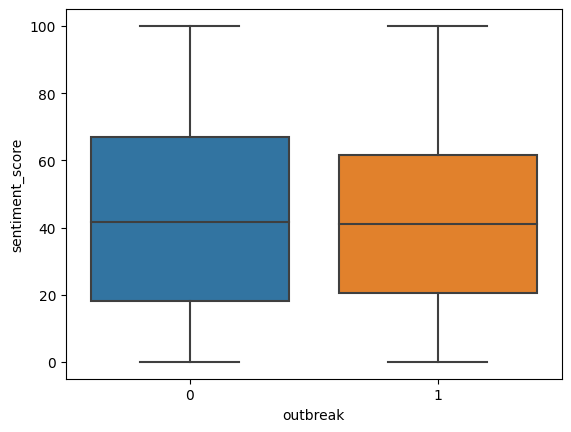

In [4]:
import seaborn as sns
sns.boxplot(x = 'outbreak', y = 'sentiment_score', data = df_fixed_effect)

In [5]:
# from datetime import datetime
# def string_to_date(date_string1):
#     date_object1 = datetime.strptime(date_string1, '%Y-%m-%d')
#     return date_object1
# df_fixed_effect['comment_day'] = df_fixed_effect['comment_day'].apply(string_to_date)


In [6]:
data_after_outbreak = df_fixed_effect[df_fixed_effect['outbreak']==1]
# data_after_outbreak

In [7]:
from statsmodels.datasets import grunfeld
# data = grunfeld.load_pandas().data
data = df_fixed_effect.set_index(["scence_id","comment_day"])
print(data.head())


                       Unnamed: 0   scence_name  sentiment_score  scence_id.1  \
scence_id comment_day                                                           
1267      2019-06-01            0  三亚市南山大小洞天旅游区        35.725343         1267   
1363      2019-06-01            1  乌鲁木齐市天山大峡谷景区        95.828390         1363   
1239      2019-06-01            2      佛山市西樵山景区        50.854552         1239   
1110      2019-06-01            3      六安市万佛湖景区        78.599554         1110   
1116      2019-06-01            4    六安市天堂寨旅游景区         8.476657         1116   

                      city_new  high_temperature  holiday  outbreak  \
scence_id comment_day                                                 
1267      2019-06-01        三亚              33.0        1         0   
1363      2019-06-01      乌鲁木齐              29.0        1         0   
1239      2019-06-01        佛山              30.0        1         0   
1110      2019-06-01        六安              31.0        1         0   
1116  

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
# sentiment_score 与 outbreak，outbreak_timeDistance，holiday，high_temperature
x = data[['outbreak','confirmed']]
y = data[['sentiment_score']]
x= sm.add_constant(x) #添加常数项
est=sm.OLS(y,x)
model=est.fit()#建立最小二乘回归模型
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        sentiment_score   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     13.55
Date:                Wed, 22 Feb 2023   Prob (F-statistic):           1.30e-06
Time:                        15:59:51   Log-Likelihood:            -4.2027e+05
No. Observations:               87954   AIC:                         8.405e+05
Df Residuals:                   87951   BIC:                         8.406e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         44.6135      0.269    165.974      0.0

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
# sentiment_score 与 outbreak，outbreak_timeDistance，holiday，high_temperature
x = data[['confirmed']]
y = data[['sentiment_score']]
x= sm.add_constant(x) #添加常数项
est=sm.OLS(y,x)
model=est.fit()#建立最小二乘回归模型
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        sentiment_score   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     10.54
Date:                Wed, 22 Feb 2023   Prob (F-statistic):            0.00117
Time:                        15:59:51   Log-Likelihood:            -4.2028e+05
No. Observations:               87954   AIC:                         8.406e+05
Df Residuals:                   87952   BIC:                         8.406e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         43.6062      0.105    415.491      0.0

In [10]:
# Coding method 1
# # sentiment_score 与 outbreak，outbreak_timeDistance，holiday，high_temperature
from linearmodels.panel import PanelOLS
import statsmodels.api as sm
exog = sm.add_constant(data[['outbreak','outbreak_timeDistance','holiday','high_temperature','Month','confirmed']])
grunfeld_fe = PanelOLS(data['sentiment_score'], exog, entity_effects=True, time_effects=False)
grunfeld_fe = grunfeld_fe.fit()
print(grunfeld_fe)

# # Coding method 2
# grunfeld_fe = PanelOLS.from_formula("invest ~ value + capital + EntityEffects", data)                          
# print(grunfeld_fe.fit())


ValueError: The index on the time dimension must be either numeric or date-like

In [ ]:
import pandas as pd
# # R2太小了。看看使用市级的数据是否能好一些
# https://raw.githubusercontent.com/canghailan/Wuhan-2019-nCoV/master/Wuhan-2019-nCoV.csv
data_2020 = pd.read_csv('https://raw.githubusercontent.com/canghailan/Wuhan-2019-nCoV/master/Wuhan-2019-nCoV.csv')
# data_2020 = data[data['country']=='中国'& data['provinceCode']>0 & int(data['cityCode'])>0 ]
data_2020

In [11]:
type(data_2020['provinceCode'][2])# float
type(data_2020['cityCode'][2])# str

NameError: name 'data_2020' is not defined

In [12]:
data_2020_china = data_2020[data_2020['country']=='中国']
data_2020_china.dropna()

NameError: name 'data_2020' is not defined

In [13]:
#  打开各市的数据
# E:\\论文\\bought_data.xlsx
import pandas as pd
df_bought_data = pd.read_csv('E:\\论文\\bought_data.csv')
df_bought_data

FileNotFoundError: [Errno 2] No such file or directory: 'E:\\论文\\bought_data.csv'

In [14]:
set1 = set(df_bought_data['市'])
len(set1)

NameError: name 'df_bought_data' is not defined

In [15]:
# # df_fixed_effect 中的city_new 和  df_bought_data中的市
# df_com1 = pd.merge(df_fixed_effect, df_bought_data, left_on = df_fixed_effect['city_new'],right_on = df_bought_data['市'],how = 'left')
# df_com1

In [16]:
from datetime import datetime

# df_new_scenceName_sentimentScore
def date_to_string(string1):
    string2=str(string1)
    string2 = string2.replace(' ','')
    return string2
df_bought_data['date_string']=df_bought_data['日期'].apply(date_to_string)

df_bought_data

NameError: name 'df_bought_data' is not defined

In [17]:
def add_string(string1,string2):
    string3 = string1.strip()+string2.strip()
    return string3

bought_data_city = list(df_bought_data['市'])
bought_data_date = list(df_bought_data['日期'])

bought_data_cityDate = zip(bought_data_city,bought_data_date)
list1 = list(bought_data_cityDate)


NameError: name 'df_bought_data' is not defined

In [18]:
len(list1)

NameError: name 'list1' is not defined

In [19]:
df_bought_data['cityDate'] = list1

NameError: name 'list1' is not defined

In [20]:
df_fixed_city = list(df_fixed_effect['city_new'])
df_fixed_date = list(df_fixed_effect['comment_day'])

df_fixed_cityDate = zip(df_fixed_city,df_fixed_date)
list2 = list(df_fixed_cityDate)

df_fixed_effect['cityDate'] = list2
list2


[('三亚', '2019-06-01'),
 ('乌鲁木齐', '2019-06-01'),
 ('佛山', '2019-06-01'),
 ('六安', '2019-06-01'),
 ('六安', '2019-06-01'),
 ('北京', '2019-06-01'),
 ('淮安', '2019-06-01'),
 ('重庆', '2019-06-01'),
 ('宜昌', '2019-06-01'),
 ('宜春', '2019-06-01'),
 ('宣城', '2019-06-01'),
 ('临沂', '2019-06-01'),
 ('常州', '2019-06-01'),
 ('平顶山', '2019-06-01'),
 ('广元', '2019-06-01'),
 ('百色', '2019-06-01'),
 ('惠州', '2019-06-01'),
 ('本溪', '2019-06-01'),
 ('重庆', '2019-06-01'),
 ('新乡', '2019-06-01'),
 ('泰安', '2019-06-01'),
 ('洛阳', '2019-06-01'),
 ('三亚', '2019-06-01'),
 ('温州', '2019-06-01'),
 ('烟台', '2019-06-01'),
 ('绍兴', '2019-06-01'),
 ('苏州', '2019-06-01'),
 ('苏州', '2019-06-01'),
 ('迪庆', '2019-06-01'),
 ('镇江', '2019-06-01'),
 ('延安', '2019-06-01'),
 ('上饶', '2019-06-02'),
 ('韶关', '2019-06-02'),
 ('乌鲁木齐', '2019-06-02'),
 ('保定', '2019-06-02'),
 ('六安', '2019-06-02'),
 ('北京', '2019-06-02'),
 ('南充', '2019-06-02'),
 ('吐鲁番', '2019-06-02'),
 ('唐山', '2019-06-02'),
 ('甘孜', '2019-06-02'),
 ('天水', '2019-06-02'),
 ('安庆', '2019-06-02'),
 ('宝鸡

In [21]:
df_bought_data['city_date'] = df_bought_data['市'] + df_bought_data['date_string']
df_bought_data['city_date']

NameError: name 'df_bought_data' is not defined

In [22]:
df_fixed_effect['city_date'] = df_fixed_effect['city_new'] + df_fixed_effect['comment_day']
df_fixed_effect['city_date'] 

0          三亚2019-06-01
1        乌鲁木齐2019-06-01
2          佛山2019-06-01
3          六安2019-06-01
4          六安2019-06-01
              ...      
87949      昆明2022-11-28
87950      毕节2022-11-28
87951      重庆2022-11-28
87952      长沙2022-11-28
87953      阿坝2022-11-28
Name: city_date, Length: 87954, dtype: object

In [23]:


# df_fixed_effect 中的city_new 和  df_bought_data中的市
df_com1 = pd.merge(df_fixed_effect, df_bought_data, on = 'cityDate',how = 'left')
df_com1

NameError: name 'df_bought_data' is not defined

In [35]:
df_com2 = df_com1.drop_duplicates()
df_com2.shape # 说明没有重复数据

(87954, 28)

In [36]:
df_null = df_com2[df_com2.isnull().T.any()]
df_null_1 = df_null[df_null['comment_day']>'2020-01-23']
df_null_1 # 10579 rows 条数据为2020-01-23之后，且累计确诊数量为空

,Unnamed: 0,comment_day,scence_id,scence_name,sentiment_score,scence_id.1,city_new,high_temperature,holiday,outbreak,...,日期,累计确诊数量,累计病死数量,累计治愈数量,新增确诊数量,新增病死数量,新增治愈数量,locIncrNum,locAsymNum,date_string
11460,11460,2020-01-24,1368,伊犁哈萨克自治州阿勒泰地区富蕴可可托海景区,36.734861,1368,伊犁,5.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11467,11467,2020-01-24,1333,宝鸡市法门寺佛文化景区,53.015620,1333,宝鸡,5.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11475,11475,2020-01-24,1277,江津四面山景区,5.419364,1277,重庆,10.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11476,11476,2020-01-24,1183,河南省洛阳栾川老君山·鸡冠洞旅游区,99.927229,1183,洛阳,4.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11490,11490,2020-01-25,1004,北京市明十三陵景区,99.927229,1004,北京,5.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87933,88378,2022-11-27,1273,重庆市彭水县阿依河景区,10.438993,1273,重庆,21.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87938,88383,2022-11-27,1300,阿坝藏族羌族自治州九寨沟旅游景区,43.040777,1300,阿坝,13.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87947,88392,2022-11-28,1319,大理市崇圣寺三塔文化旅游区,91.645581,1319,大理,20.0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87951,88396,2022-11-28,1282,酉阳桃花源旅游景区,87.084818,1282,重庆,19.0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
# 将2020-01-23之前全部的数据
# 2020-01-23之后的非空数据整合
df_before_outbreak = df_com2[df_com2['comment_day']<'2020-01-23'] # 11438条数据
df_after_outbreak = df_com2[df_com2['comment_day']>='2020-01-23'] # 76516条数据
df_after_outbreak_not_null = df_after_outbreak.dropna(axis=0, how='any')
df_after_outbreak_not_null # 65933数据

,Unnamed: 0,comment_day,scence_id,scence_name,sentiment_score,scence_id.1,city_new,high_temperature,holiday,outbreak,...,日期,累计确诊数量,累计病死数量,累计治愈数量,新增确诊数量,新增病死数量,新增治愈数量,locIncrNum,locAsymNum,date_string
11438,11438,2020-01-23,1243,中国丹霞山世界地质公园,21.625140,1243,韶关,24.0,0,0,...,2020-01-23,3.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,2020-01-23
11439,11439,2020-01-23,1110,六安市万佛湖景区,25.919751,1110,六安,8.0,0,0,...,2020-01-23,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2020-01-23
11440,11440,2020-01-23,1016,唐山市清东陵景区,19.516103,1016,唐山,7.0,0,0,...,2020-01-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020-01-23
11442,11442,2020-01-23,1345,天水市麦积山景区,54.487001,1345,天水,5.0,0,0,...,2020-01-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020-01-23
11444,11444,2020-01-23,1159,山东省沂蒙山旅游区,97.747481,1159,临沂,10.0,0,0,...,2020-01-23,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020-01-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87946,88391,2022-11-28,1257,南宁市青秀山旅游区,49.181391,1257,南宁,30.0,0,1,...,2022-11-28,70.0,0.0,70.0,0.0,0.0,0.0,0.0,23.0,2022-11-28
87948,88393,2022-11-28,1232,惠州市惠州西湖旅游景区,6.762798,1232,惠州,27.0,0,1,...,2022-11-28,286.0,0.0,156.0,0.0,0.0,0.0,8.0,13.0,2022-11-28
87949,88394,2022-11-28,1317,昆明市昆明世博园景区,12.635818,1317,昆明,23.0,0,1,...,2022-11-28,736.0,0.0,75.0,0.0,0.0,0.0,48.0,214.0,2022-11-28
87950,88395,2022-11-28,1313,毕节市百里杜鹃景区,37.496600,1313,毕节,23.0,0,1,...,2022-11-28,581.0,0.0,550.0,0.0,0.0,0.0,0.0,32.0,2022-11-28


In [48]:
df_com3 = df_before_outbreak.append(df_after_outbreak_not_null)
df_com3

,Unnamed: 0,comment_day,scence_id,scence_name,sentiment_score,scence_id.1,city_new,high_temperature,holiday,outbreak,...,日期,累计确诊数量,累计病死数量,累计治愈数量,新增确诊数量,新增病死数量,新增治愈数量,locIncrNum,locAsymNum,date_string
0,0,2019-06-01,1267,三亚市南山大小洞天旅游区,35.725343,1267,三亚,33.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2019-06-01,1363,乌鲁木齐市天山大峡谷景区,95.828390,1363,乌鲁木齐,29.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2019-06-01,1239,佛山市西樵山景区,50.854552,1239,佛山,30.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2019-06-01,1110,六安市万佛湖景区,78.599554,1110,六安,31.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2019-06-01,1116,六安市天堂寨旅游景区,8.476657,1116,六安,31.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87946,88391,2022-11-28,1257,南宁市青秀山旅游区,49.181391,1257,南宁,30.0,0,1,...,2022-11-28,70.0,0.0,70.0,0.0,0.0,0.0,0.0,23.0,2022-11-28
87948,88393,2022-11-28,1232,惠州市惠州西湖旅游景区,6.762798,1232,惠州,27.0,0,1,...,2022-11-28,286.0,0.0,156.0,0.0,0.0,0.0,8.0,13.0,2022-11-28
87949,88394,2022-11-28,1317,昆明市昆明世博园景区,12.635818,1317,昆明,23.0,0,1,...,2022-11-28,736.0,0.0,75.0,0.0,0.0,0.0,48.0,214.0,2022-11-28
87950,88395,2022-11-28,1313,毕节市百里杜鹃景区,37.496600,1313,毕节,23.0,0,1,...,2022-11-28,581.0,0.0,550.0,0.0,0.0,0.0,0.0,32.0,2022-11-28


In [ ]:
df_null_2 = df_null_1[['comment_day','city_new']]
df_null_2.to_csv('缺少的数据_日期_城市.csv',encoding = 'utf-8-sig')

In [47]:
df_com3 = df_com2.dropna()
df_com3

,Unnamed: 0,comment_day,scence_id,scence_name,sentiment_score,scence_id.1,city_new,high_temperature,holiday,outbreak,...,日期,累计确诊数量,累计病死数量,累计治愈数量,新增确诊数量,新增病死数量,新增治愈数量,locIncrNum,locAsymNum,date_string
11429,11429,2020-01-22,1255,桂林市两江四湖·象山景区,88.170367,1255,桂林,15.0,0,0,...,2020-01-22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020-01-22
11438,11438,2020-01-23,1243,中国丹霞山世界地质公园,21.625140,1243,韶关,24.0,0,0,...,2020-01-23,3.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,2020-01-23
11439,11439,2020-01-23,1110,六安市万佛湖景区,25.919751,1110,六安,8.0,0,0,...,2020-01-23,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2020-01-23
11440,11440,2020-01-23,1016,唐山市清东陵景区,19.516103,1016,唐山,7.0,0,0,...,2020-01-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020-01-23
11442,11442,2020-01-23,1345,天水市麦积山景区,54.487001,1345,天水,5.0,0,0,...,2020-01-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020-01-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87946,88391,2022-11-28,1257,南宁市青秀山旅游区,49.181391,1257,南宁,30.0,0,1,...,2022-11-28,70.0,0.0,70.0,0.0,0.0,0.0,0.0,23.0,2022-11-28
87948,88393,2022-11-28,1232,惠州市惠州西湖旅游景区,6.762798,1232,惠州,27.0,0,1,...,2022-11-28,286.0,0.0,156.0,0.0,0.0,0.0,8.0,13.0,2022-11-28
87949,88394,2022-11-28,1317,昆明市昆明世博园景区,12.635818,1317,昆明,23.0,0,1,...,2022-11-28,736.0,0.0,75.0,0.0,0.0,0.0,48.0,214.0,2022-11-28
87950,88395,2022-11-28,1313,毕节市百里杜鹃景区,37.496600,1313,毕节,23.0,0,1,...,2022-11-28,581.0,0.0,550.0,0.0,0.0,0.0,0.0,32.0,2022-11-28


## df_com3进行OLS回归
- sentiment_score 与 period
- sentiment_score 与 period，outbreak_timeDistance，holiday，high_temperature
- sentiment_score 与 period，outbreak_timeDistance，holiday，high_temperature,spot(固定效应模型)

In [49]:
df_com3.columns

Index(['Unnamed: 0', 'comment_day', 'scence_id', 'scence_name',
       'sentiment_score', 'scence_id.1', 'city_new', 'high_temperature',
       'holiday', 'outbreak', 'outbreak_timeDistance', 'period', 'Month',
       'level', 'confirmed', 'cityDate', '市', '市代码', '日期', '累计确诊数量', '累计病死数量',
       '累计治愈数量', '新增确诊数量', '新增病死数量', '新增治愈数量', 'locIncrNum', 'locAsymNum',
       'date_string'],
      dtype='object')

In [50]:
# sentiment_score 与 period
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
x = df_com3['period']
y = df_com3['sentiment_score']
x= sm.add_constant(x) #添加常数项
est=sm.OLS(y,x)
model=est.fit()#建立最小二乘回归模型
print(model.summary())
# sentiment(it) = 44.6127 -1.3158*outbreak(it),且outbreak对应的p值小于0.05***

                            OLS Regression Results                            
Dep. Variable:        sentiment_score   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     3.000
Date:                Wed, 15 Feb 2023   Prob (F-statistic):             0.0833
Time:                        21:42:48   Log-Likelihood:            -3.7005e+05
No. Observations:               77371   AIC:                         7.401e+05
Df Residuals:                   77369   BIC:                         7.401e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         43.9276      0.224    195.840      0.0

In [57]:
# # sentiment_score 与 outbreak，outbreak_timeDistance，holiday，high_temperature
# x =  df_com3[['period', '新增确诊数量', '新增病死数量', '新增治愈数量','holiday','high_temperature','Month']]
# y =  df_com3[['sentiment_score']]
# x= sm.add_constant(x) #添加常数项
# est=sm.OLS(y,x)
# model=est.fit()#建立最小二乘回归模型
# print(model.summary())


In [56]:
# from datetime import datetime
# def string_to_date(date_string1):
#     date_object1 = datetime.strptime(date_string1, '%Y-%m-%d')
#     return date_object1
# df_com3['comment_day'] = df_com3['comment_day'].apply(string_to_date)

In [1]:
# Coding method 1
# # sentiment_score 与 outbreak，outbreak_timeDistance，holiday，high_temperature
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

data = df_com3.set_index(["scence_id","comment_day"])

exog = sm.add_constant(data[['period', '新增确诊数量', '新增病死数量', '新增治愈数量', '累计确诊数量', '累计病死数量',
       '累计治愈数量','locIncrNum', 'locAsymNum','holiday','high_temperature','Month']])
grunfeld_fe = PanelOLS(data['sentiment_score'], exog, entity_effects=True, time_effects=True,)
grunfeld_fe = grunfeld_fe.fit()
print(grunfeld_fe)

# # Coding method 2
# grunfeld_fe = PanelOLS.from_formula("invest ~ value + capital + EntityEffects", data)                          
# print(grunfeld_fe.fit())


NameError: name 'df_com3' is not defined

- 查看2020-01-23前有哪些城市
- 2020-01-23之后有哪些城市

In [1]:
# 打开df_com3
import pandas as pd
df_com3 = pd.read_csv('E:\\论文\\第二篇论文\\ df_before_outbreak.append_df_after_outbreak_not_null.csv',encoding = 'utf-8-sig')
df_com3

,Unnamed: 0,Unnamed: 0.1,comment_day,scence_id,scence_name,sentiment_score,scence_id.1,city_new,high_temperature,holiday,...,日期,累计确诊数量,累计病死数量,累计治愈数量,新增确诊数量,新增病死数量,新增治愈数量,locIncrNum,locAsymNum,date_string
0,0,0,2019-06-01,1267,三亚市南山大小洞天旅游区,35.725343,1267,三亚,33.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,2019-06-01,1363,乌鲁木齐市天山大峡谷景区,95.828390,1363,乌鲁木齐,29.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2,2019-06-01,1239,佛山市西樵山景区,50.854552,1239,佛山,30.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,3,2019-06-01,1110,六安市万佛湖景区,78.599554,1110,六安,31.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,4,2019-06-01,1116,六安市天堂寨旅游景区,8.476657,1116,六安,31.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77366,87946,88391,2022-11-28,1257,南宁市青秀山旅游区,49.181391,1257,南宁,30.0,0,...,2022-11-28,70.0,0.0,70.0,0.0,0.0,0.0,0.0,23.0,2022-11-28
77367,87948,88393,2022-11-28,1232,惠州市惠州西湖旅游景区,6.762798,1232,惠州,27.0,0,...,2022-11-28,286.0,0.0,156.0,0.0,0.0,0.0,8.0,13.0,2022-11-28
77368,87949,88394,2022-11-28,1317,昆明市昆明世博园景区,12.635818,1317,昆明,23.0,0,...,2022-11-28,736.0,0.0,75.0,0.0,0.0,0.0,48.0,214.0,2022-11-28
77369,87950,88395,2022-11-28,1313,毕节市百里杜鹃景区,37.496600,1313,毕节,23.0,0,...,2022-11-28,581.0,0.0,550.0,0.0,0.0,0.0,0.0,32.0,2022-11-28


In [2]:
df_before_outbreak = df_com3[df_com3['comment_day']<'2020-01-23']
df_after_outbreak = df_com3[df_com3['comment_day']>='2020-01-23']
list_before_outbreak_city = list(df_before_outbreak['city_new'])
list_before_outbreak_scence = list(df_before_outbreak['scence_name'])

list_after_outbreak_city = list(df_after_outbreak['city_new'])
list_after_outbreak_scence = list(df_after_outbreak['scence_name'])

list_before_outbreak_cityScence = set(zip(list_before_outbreak_city,list_before_outbreak_scence))
list_after_outbreak_cityScence = set(zip(list_after_outbreak_city,list_after_outbreak_scence))

print(len(list_before_outbreak_cityScence)) # 2020-01-23之前有199个城市
print(len(list_after_outbreak_cityScence))  # 2020-01-23之后有235个城市
# 之前之后相交的地方为174个

199
235


In [3]:
set_before_outbreak_scence = set(df_before_outbreak['scence_name'])
set_after_outbreak_scence = set(df_after_outbreak['scence_name'])

set_intersection_scence = set_before_outbreak_scence.intersection(set_after_outbreak_scence)
len(set_intersection_scence)

174

In [4]:
set_intersection_cityScence = list_before_outbreak_cityScence.intersection(list_after_outbreak_cityScence)
len(set_intersection_cityScence)

174

In [5]:
set_intersection_cityScence

{('三亚', '三亚市南山大小洞天旅游区'),
 ('三亚', '三亚市南山文化旅游区'),
 ('三亚', '海南呀诺达雨林文化旅游区'),
 ('三亚', '海南槟榔谷黎苗文化旅游区'),
 ('三明', '三明市泰宁风景名胜区'),
 ('上饶', '上饶市三清山旅游景区'),
 ('上饶', '上饶市婺源江湾景区'),
 ('上饶', '上饶市龟峰景区'),
 ('东营', '山东省东营市黄河口生态旅游区'),
 ('中卫', '中卫市沙坡头旅游景区'),
 ('中山', '中山市孙中山故里旅游区'),
 ('临汾', '临汾市洪洞县洪洞大槐树寻根祭祖园旅游景区'),
 ('临沂', '山东省沂蒙山旅游区'),
 ('丽水', '浙江省丽水市缙云仙都景区'),
 ('乌鲁木齐', '乌鲁木齐市天山大峡谷景区'),
 ('乐山', '乐山市峨眉山景区'),
 ('九江', '九江市庐山风景名胜区'),
 ('伊春', '伊春市汤旺河林海奇石景区'),
 ('佛山', '佛山市西樵山景区'),
 ('佛山', '佛山市长鹿旅游休博园'),
 ('保定', '保定市安新白洋淀景区'),
 ('保定', '保定市白石山景区'),
 ('保定', '保定市野三坡景区'),
 ('保定', '河北省保定市清西陵景区'),
 ('六安', '六安市万佛湖景区'),
 ('六安', '六安市天堂寨旅游景区'),
 ('兴安盟', '阿尔山·柴河旅游景区'),
 ('十堰', '十堰市武当山风景区'),
 ('南京', '南京市钟山风景名胜区·中山陵园风景区'),
 ('南充', '南充市仪陇朱德故里景区'),
 ('南阳', '南阳市西峡伏牛山老界岭·恐龙遗址园旅游区'),
 ('台州', '台州市神仙居景区'),
 ('合肥', '合肥市三河古镇景区'),
 ('吐鲁番', '吐鲁番市葡萄沟风景区'),
 ('吐鲁番', '巴音郭楞蒙古自治州博斯腾湖景区'),
 ('吐鲁番', '巴音郭楞蒙古自治州和静县巴音布鲁克景区'),
 ('呼伦贝尔', '满洲里市中俄边境旅游区'),
 ('咸宁', '咸宁市赤壁市三国赤壁古战场景区'),
 ('哈尔滨', '哈尔滨市太阳岛景区'),
 ('唐山', '唐山市清东陵景区'),
 ('商洛', '商洛市金丝峡景区'),
 ('喀什

- 从大众点评上搜集以上景点的票价、得分、总评论数、好评数、中评数、差评数

In [ ]:
# df_after_outbreak 
df_after_outbreak['sentiment_score']

## - 计量模型的选择
1. 混合回归模型
- 要求：不同年份、不同个体之间不存在显著差异
- 我们的数据不符合这一要求，pass
2. 固定效应模型
- 解释变量不包含一些被解释变量的不可测的确定性因素；
- 采用反应个体特征或时间特征的虚拟变量
- 固定效应模型分为个体固定效应模型、时点固定效应模型、时点个体固定效应模型。

In [10]:
df_merge_before_after = pd.merge(df_before_outbreak, df_after_outbreak,on = ['scence_name'])
# df_com1 = pd.merge(df_fixed_effect, df_bought_data, left_on = df_fixed_effect['city_new'],right_on = df_bought_data['市'],how = 'left')
df_merge_before_after

,Unnamed: 0_x,Unnamed: 0.1_x,comment_day_x,scence_id_x,scence_name,sentiment_score_x,scence_id.1_x,city_new_x,high_temperature_x,holiday_x,...,日期_y,累计确诊数量_y,累计病死数量_y,累计治愈数量_y,新增确诊数量_y,新增病死数量_y,新增治愈数量_y,locIncrNum_y,locAsymNum_y,date_string_y
0,0,0,2019-06-01,1267,三亚市南山大小洞天旅游区,35.725343,1267,三亚,33.0,1,...,2020-01-24,5.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,2020-01-24
1,0,0,2019-06-01,1267,三亚市南山大小洞天旅游区,35.725343,1267,三亚,33.0,1,...,2020-02-02,17.0,0.0,3.0,0.0,0.0,2.0,0.0,0.0,2020-02-02
2,0,0,2019-06-01,1267,三亚市南山大小洞天旅游区,35.725343,1267,三亚,33.0,1,...,2020-02-07,37.0,1.0,9.0,5.0,0.0,3.0,0.0,0.0,2020-02-07
3,0,0,2019-06-01,1267,三亚市南山大小洞天旅游区,35.725343,1267,三亚,33.0,1,...,2020-02-12,54.0,1.0,11.0,8.0,0.0,0.0,0.0,0.0,2020-02-12
4,0,0,2019-06-01,1267,三亚市南山大小洞天旅游区,35.725343,1267,三亚,33.0,1,...,2020-02-27,54.0,1.0,43.0,0.0,0.0,0.0,0.0,0.0,2020-02-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3628625,11182,11182,2020-01-13,1341,西安市秦始皇兵马俑博物馆,97.747481,1341,西安,5.0,0,...,2022-11-16,2753.0,3.0,2561.0,0.0,0.0,0.0,2.0,114.0,2022-11-16
3628626,11182,11182,2020-01-13,1341,西安市秦始皇兵马俑博物馆,97.747481,1341,西安,5.0,0,...,2022-11-17,2756.0,3.0,2561.0,0.0,0.0,0.0,3.0,173.0,2022-11-17
3628627,11182,11182,2020-01-13,1341,西安市秦始皇兵马俑博物馆,97.747481,1341,西安,5.0,0,...,2022-11-22,2779.0,3.0,2561.0,0.0,0.0,0.0,3.0,241.0,2022-11-22
3628628,11182,11182,2020-01-13,1341,西安市秦始皇兵马俑博物馆,97.747481,1341,西安,5.0,0,...,2022-11-23,2784.0,3.0,2561.0,0.0,0.0,0.0,5.0,210.0,2022-11-23


In [16]:
set_before_scence = set(df_before_outbreak['scence_name'])
len(set_before_scence)

199

In [17]:
set_after_scence = set(df_after_outbreak['scence_name'])
len(set_after_scence)

235

In [18]:
set_intersection_scence1 = [x for x in set_before_scence if x in set_after_scence]
len(set_intersection_scence1)

174

In [32]:
dict_intersection_scence1 = dict(zip(range(len(set_intersection_scence1)),set_intersection_scence1))
df_intersection_scence1 = pd.DataFrame(data =dict_intersection_scence1,index = ['scence_name']).T
df_intersection_scence1

,scence_name
0,巴音郭楞蒙古自治州博斯腾湖景区
1,桂林市两江四湖·象山景区
2,江苏省无锡市惠山古镇景区
3,龙岩市古田旅游区
4,武汉市黄陂木兰文化生态旅游区
...,...
169,广东省肇庆市星湖旅游景区
170,西安市大雁塔·大唐芙蓉园景区
171,海东市互助土族故土园旅游区
172,崇左市德天跨国瀑布景区


In [35]:
df_before_outbreak1 = pd.merge(df_before_outbreak, df_intersection_scence1,on ='scence_name',how = 'inner')
df_after_outbreak1 = pd.merge(df_after_outbreak, df_intersection_scence1,on ='scence_name',how = 'inner')
print(len(df_before_outbreak1))
print(len(df_after_outbreak1))

10573
54610


In [44]:
# df_outbreak1 = df_before_outbreak1.extend(df_after_outbreak1)
# df_outbreak1 =  

from datetime import datetime
def string_to_date(date_string1):
    date_object1 = datetime.strptime(date_string1, '%Y-%m-%d')
    return date_object1

df_before_outbreak1['comment_day'] = df_before_outbreak1 ['comment_day'].apply(string_to_date)
df_after_outbreak1['comment_day'] = df_after_outbreak1 ['comment_day'].apply(string_to_date)


df_outbreak1 = pd.concat([df_before_outbreak1, df_after_outbreak1], axis = 0)
df_outbreak1 


,Unnamed: 0,Unnamed: 0.1,comment_day,scence_id,scence_name,sentiment_score,scence_id.1,city_new,high_temperature,holiday,...,日期,累计确诊数量,累计病死数量,累计治愈数量,新增确诊数量,新增病死数量,新增治愈数量,locIncrNum,locAsymNum,date_string
0,0,0,2019-06-01,1267,三亚市南山大小洞天旅游区,35.725343,1267,三亚,33.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,210,210,2019-06-08,1267,三亚市南山大小洞天旅游区,10.121588,1267,三亚,34.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,360,360,2019-06-10,1267,三亚市南山大小洞天旅游区,4.276742,1267,三亚,35.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2187,2187,2019-07-18,1267,三亚市南山大小洞天旅游区,2.195972,1267,三亚,33.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2678,2678,2019-07-26,1267,三亚市南山大小洞天旅游区,8.690529,1267,三亚,32.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54605,73347,73792,2022-08-15,1349,海东市互助土族故土园旅游区,27.328423,1349,海东,22.0,0,...,2022-08-15,5.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,2022-08-15
54606,74146,74591,2022-08-20,1349,海东市互助土族故土园旅游区,26.786906,1349,海东,29.0,1,...,2022-08-20,5.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,2022-08-20
54607,74322,74767,2022-08-21,1349,海东市互助土族故土园旅游区,49.369150,1349,海东,26.0,1,...,2022-08-21,5.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,2022-08-21
54608,82164,82609,2022-10-13,1349,海东市互助土族故土园旅游区,38.309836,1349,海东,10.0,0,...,2022-10-13,10.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,2022-10-13


In [80]:
# Coding method 1
# # sentiment_score 与 outbreak，outbreak_timeDistance，holiday，high_temperature
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

data = df_after_outbreak1.set_index(["scence_id","comment_day"])

exog = sm.add_constant(data[['period', '新增确诊数量', '新增病死数量', '新增治愈数量','locIncrNum', 'locAsymNum','holiday','high_temperature','Month']])
grunfeld_fe = PanelOLS(data['sentiment_score'], exog, entity_effects= True, time_effects= False)
grunfeld_fe = grunfeld_fe.fit()
print(grunfeld_fe)

# # Coding method 2
# grunfeld_fe = PanelOLS.from_formula("invest ~ value + capital + EntityEffects", data)                          
# print(grunfeld_fe.fit())


                          PanelOLS Estimation Summary                           
Dep. Variable:        sentiment_score   R-squared:                        0.0012
Estimator:                   PanelOLS   R-squared (Between):             -0.0106
No. Observations:               54610   R-squared (Within):               0.0012
Date:                Sun, Feb 19 2023   R-squared (Overall):              0.0006
Time:                        18:20:08   Log-likelihood                -2.614e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      6.9912
Entities:                         174   P-value                           0.0000
Avg Obs:                       313.85   Distribution:                 F(9,54427)
Min Obs:                       8.0000                                           
Max Obs:                       674.00   F-statistic (robust):             6.9912
                            

##  将period和Month都设置成哑变量的形式

In [35]:
set(df_outbreak1['period']) # {0, 1, 2, 3, 4, 5}
def period_before(int0):
    if int0 ==0:
        return 1
    else:
        return 0

def period_1(int0):
    if int0 ==1:
        return 1
    else:
        return 0    
    
def period_2(int0):
    if int0 ==2:
        return 1
    else:
        return 0   
    
    
def period_3(int0):
    if int0 ==3:
        return 1
    else:
        return 0   
    
def period_4(int0):
    if int0 ==4:
        return 1
    else:
        return 0   
    
def period_5(int0):
    if int0 ==5:
        return 1
    else:
        return 0   
    

df_outbreak1['period_before'] = df_outbreak1['period'].apply(period_before)
df_outbreak1['period_1'] = df_outbreak1['period'].apply(period_1)
df_outbreak1['period_2'] = df_outbreak1['period'].apply(period_2)
df_outbreak1['period_3'] = df_outbreak1['period'].apply(period_3)
df_outbreak1['period_4'] = df_outbreak1['period'].apply(period_4)
df_outbreak1['period_5'] = df_outbreak1['period'].apply(period_5)


NameError: name 'df_outbreak1' is not defined

In [71]:
set(df_outbreak1['Month'])

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}

In [72]:
set(df_outbreak1['Month']) # {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}
def Month_1(int0):
    if int0 ==1:
        return 1
    else:
        return 0

def Month_2(int0):
    if int0 ==2:
        return 1
    else:
        return 0    
    
def Month_3(int0):
    if int0 ==3:
        return 1
    else:
        return 0   
    
    
def Month_4(int0):
    if int0 ==4:
        return 1
    else:
        return 0   
    
def Month_5(int0):
    if int0 ==5:
        return 1
    else:
        return 0   
    
def Month_6(int0):
    if int0 ==6:
        return 1
    else:
        return 0   

def Month_7(int0):
    if int0 ==7:
        return 1
    else:
        return 0  
    
def Month_8(int0):
    if int0 ==8:
        return 1
    else:
        return 0  
    
def Month_9(int0):
    if int0 ==9:
        return 1
    else:
        return 0  

def Month_10(int0):
    if int0 ==10:
        return 1
    else:
        return 0  
    
def Month_11(int0):
    if int0 ==11:
        return 1
    else:
        return 0  

def Month_12(int0):
    if int0 ==12:
        return 1
    else:
        return 0  



df_outbreak1['Month_1'] = df_outbreak1['Month'].apply(Month_1)
df_outbreak1['Month_2'] = df_outbreak1['Month'].apply(Month_2)
df_outbreak1['Month_3'] = df_outbreak1['Month'].apply(Month_3)
df_outbreak1['Month_4'] = df_outbreak1['Month'].apply(Month_4)
df_outbreak1['Month_5'] = df_outbreak1['Month'].apply(Month_5)
df_outbreak1['Month_6'] = df_outbreak1['Month'].apply(Month_6)
df_outbreak1['Month_7'] = df_outbreak1['Month'].apply(Month_7)
df_outbreak1['Month_8'] = df_outbreak1['Month'].apply(Month_8)
df_outbreak1['Month_9'] = df_outbreak1['Month'].apply(Month_9)
df_outbreak1['Month_10'] = df_outbreak1['Month'].apply(Month_10)
df_outbreak1['Month_11'] = df_outbreak1['Month'].apply(Month_11)
df_outbreak1['Month_12'] = df_outbreak1['Month'].apply(Month_12)

In [78]:
df_after_outbreak1  = df_outbreak1[df_outbreak1['comment_day']>'2020-01-22']

In [79]:
# 设置哑变量后来跑回归
# Coding method 1
# # sentiment_score 与 outbreak，outbreak_timeDistance，holiday，high_temperature
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

data = df_after_outbreak1.set_index(["scence_id","comment_day"])

exog = sm.add_constant(data[['period_1', 'period_2','period_3','period_4','新增确诊数量', '新增病死数量', '新增治愈数量','locIncrNum', 'locAsymNum','holiday','high_temperature','Month_1','Month_2','Month_3','Month_4','Month_5','Month_6','Month_7','Month_8','Month_9','Month_10','Month_11']])
grunfeld_fe = PanelOLS(data['sentiment_score'], exog, entity_effects= True, time_effects= False)
grunfeld_fe = grunfeld_fe.fit()
print(grunfeld_fe)

# # Coding method 2
# grunfeld_fe = PanelOLS.from_formula("invest ~ value + capital + EntityEffects", data)                          
# print(grunfeld_fe.fit())

# R2从0.0012到0.002了哈哈哈
# 待会把大众的数据找了试一试

                          PanelOLS Estimation Summary                           
Dep. Variable:        sentiment_score   R-squared:                        0.0020
Estimator:                   PanelOLS   R-squared (Between):             -0.0012
No. Observations:               54610   R-squared (Within):               0.0020
Date:                Sun, Feb 19 2023   R-squared (Overall):              0.0016
Time:                        18:19:43   Log-likelihood                -2.614e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      5.0225
Entities:                         174   P-value                           0.0000
Avg Obs:                       313.85   Distribution:                F(22,54414)
Min Obs:                       8.0000                                           
Max Obs:                       674.00   F-statistic (robust):             5.0225
                            

## df_fixed_effect
## 将df_fixed_effect中的month和period设置成哑变量

In [3]:
from datetime import datetime
def string_to_date(date_string1):
    date_object1 = datetime.strptime(date_string1, '%Y-%m-%d')
    return date_object1
df_fixed_effect['comment_day'] = df_fixed_effect['comment_day'].apply(string_to_date)

In [4]:
df_fixed_effect.keys()

Index(['Unnamed: 0', 'comment_day', 'scence_id', 'scence_name',
       'sentiment_score', 'scence_id.1', 'city_new', 'high_temperature',
       'holiday', 'outbreak', 'outbreak_timeDistance', 'period', 'Month',
       'level', 'confirmed'],
      dtype='object')

In [5]:

# set(df_fixed_effect['period']) # {0, 1, 2, 3, 4, 5}
def period_before(int0):
    if int0 ==0:
        return 1
    else:
        return 0

def period_1(int0):
    if int0 ==1:
        return 1
    else:
        return 0    
    
def period_2(int0):
    if int0 ==2:
        return 1
    else:
        return 0   
    
    
def period_3(int0):
    if int0 ==3:
        return 1
    else:
        return 0   
    
def period_4(int0):
    if int0 ==4:
        return 1
    else:
        return 0   
    
def period_5(int0):
    if int0 ==5:
        return 1
    else:
        return 0   
    

df_fixed_effect['period_before'] = df_fixed_effect['period'].apply(period_before)
df_fixed_effect['period_1'] = df_fixed_effect['period'].apply(period_1)
df_fixed_effect['period_2'] = df_fixed_effect['period'].apply(period_2)
df_fixed_effect['period_3'] = df_fixed_effect['period'].apply(period_3)
df_fixed_effect['period_4'] = df_fixed_effect['period'].apply(period_4)
df_fixed_effect['period_5'] = df_fixed_effect['period'].apply(period_5)



In [6]:
set(df_fixed_effect['Month']) # {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}
def Month_1(int0):
    if int0 ==1:
        return 1
    else:
        return 0

def Month_2(int0):
    if int0 ==2:
        return 1
    else:
        return 0    
    
def Month_3(int0):
    if int0 ==3:
        return 1
    else:
        return 0   
    
    
def Month_4(int0):
    if int0 ==4:
        return 1
    else:
        return 0   
    
def Month_5(int0):
    if int0 ==5:
        return 1
    else:
        return 0   
    
def Month_6(int0):
    if int0 ==6:
        return 1
    else:
        return 0   

def Month_7(int0):
    if int0 ==7:
        return 1
    else:
        return 0  
    
def Month_8(int0):
    if int0 ==8:
        return 1
    else:
        return 0  
    
def Month_9(int0):
    if int0 ==9:
        return 1
    else:
        return 0  

def Month_10(int0):
    if int0 ==10:
        return 1
    else:
        return 0  
    
def Month_11(int0):
    if int0 ==11:
        return 1
    else:
        return 0  

def Month_12(int0):
    if int0 ==12:
        return 1
    else:
        return 0  



df_fixed_effect['Month_1'] = df_fixed_effect['Month'].apply(Month_1)
df_fixed_effect['Month_2'] = df_fixed_effect['Month'].apply(Month_2)
df_fixed_effect['Month_3'] = df_fixed_effect['Month'].apply(Month_3)
df_fixed_effect['Month_4'] = df_fixed_effect['Month'].apply(Month_4)
df_fixed_effect['Month_5'] = df_fixed_effect['Month'].apply(Month_5)
df_fixed_effect['Month_6'] = df_fixed_effect['Month'].apply(Month_6)
df_fixed_effect['Month_7'] = df_fixed_effect['Month'].apply(Month_7)
df_fixed_effect['Month_8'] = df_fixed_effect['Month'].apply(Month_8)
df_fixed_effect['Month_9'] = df_fixed_effect['Month'].apply(Month_9)
df_fixed_effect['Month_10'] = df_fixed_effect['Month'].apply(Month_10)
df_fixed_effect['Month_11'] = df_fixed_effect['Month'].apply(Month_11)
df_fixed_effect['Month_12'] = df_fixed_effect['Month'].apply(Month_12)

In [7]:
df_fixed_effect['outbreak'].mean()

0.8697387270618733

In [8]:
# 设置哑变量后来跑回归
# Coding method 1
# # sentiment_score 与 outbreak，outbreak_timeDistance，holiday，high_temperature
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

df_after_fixed = df_fixed_effect[df_fixed_effect['outbreak']== True]

# 待会把大众的数据找了试一试

In [9]:
# 这里有语法错误
data = df_after_fixed.set_index(["scence_id","comment_day"])

exog = sm.add_constant(data[['period_1', 'period_2','period_3','period_4','confirmed','holiday','high_temperature','Month_1','Month_2','Month_3','Month_4','Month_5','Month_6','Month_7','Month_8','Month_9','Month_10','Month_11']])


# # Coding method 2
# grunfeld_fe = PanelOLS.from_formula("invest ~ value + capital + EntityEffects", data)                          
# print(grunfeld_fe.fit())

# R2从0.0012到0.002了哈哈哈

In [10]:
type(exog)

pandas.core.frame.DataFrame

In [11]:
grunfeld_fe = PanelOLS(data['sentiment_score'],exog, entity_effects=True, time_effects= False)
#  exog = True, entity_effects= False, time_effects= True, check_rank=True
grunfeld_fe

PanelOLS 
Num exog: 19, Constant: True
Entity Effects: True, Time Effects: False, Num Other Effects: 0
id: 0x25eda671e48

In [12]:
grunfeld_fe = grunfeld_fe.fit()
print(grunfeld_fe)
# R2上升到0.0024了哈哈哈

                          PanelOLS Estimation Summary                           
Dep. Variable:        sentiment_score   R-squared:                        0.0024
Estimator:                   PanelOLS   R-squared (Between):             -0.0500
No. Observations:               76497   R-squared (Within):               0.0024
Date:                Thu, Feb 23 2023   R-squared (Overall):              0.0009
Time:                        20:15:41   Log-likelihood                -3.637e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      10.141
Entities:                         273   P-value                           0.0000
Avg Obs:                       280.21   Distribution:                F(18,76206)
Min Obs:                       1.0000                                           
Max Obs:                       674.00   F-statistic (robust):             10.141
                            

In [13]:
df_fixed_effect['outbreak'] =df_fixed_effect['comment_day']>'2020-01-22'

In [14]:
data

,,Unnamed: 0,scence_name,sentiment_score,scence_id.1,city_new,high_temperature,holiday,outbreak,outbreak_timeDistance,period,...,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
scence_id,comment_day,,,,,,,,,,,,,,,,,,,,,
1267,2020-01-24,11457,三亚市南山大小洞天旅游区,39.908063,1267,三亚,29.0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
1243,2020-01-24,11458,中国丹霞山世界地质公园,10.203375,1243,韶关,19.0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
1087,2020-01-24,11459,中央电视台无锡影视基地三国水浒景区,16.160673,1087,无锡,9.0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
1368,2020-01-24,11460,伊犁哈萨克自治州阿勒泰地区富蕴可可托海景区,36.734861,1368,伊犁,5.0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
1110,2020-01-24,11461,六安市万佛湖景区,0.809172,1110,六安,7.0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1317,2022-11-28,88394,昆明市昆明世博园景区,12.635818,1317,昆明,23.0,0,1,0,5,...,0,0,0,0,0,0,0,0,1,0
1313,2022-11-28,88395,毕节市百里杜鹃景区,37.496600,1313,毕节,23.0,0,1,0,5,...,0,0,0,0,0,0,0,0,1,0
1282,2022-11-28,88396,酉阳桃花源旅游景区,87.084818,1282,重庆,19.0,0,1,0,5,...,0,0,0,0,0,0,0,0,1,0


In [15]:
exog

,,const,period_1,period_2,period_3,period_4,confirmed,holiday,high_temperature,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11
scence_id,comment_day,,,,,,,,,,,,,,,,,,,
1267,2020-01-24,1.0,1,0,0,0,457.0,1,29.0,1,0,0,0,0,0,0,0,0,0,0
1243,2020-01-24,1.0,1,0,0,0,457.0,1,19.0,1,0,0,0,0,0,0,0,0,0,0
1087,2020-01-24,1.0,1,0,0,0,457.0,1,9.0,1,0,0,0,0,0,0,0,0,0,0
1368,2020-01-24,1.0,1,0,0,0,457.0,1,5.0,1,0,0,0,0,0,0,0,0,0,0
1110,2020-01-24,1.0,1,0,0,0,457.0,1,7.0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1317,2022-11-28,1.0,0,0,0,0,3624.0,0,23.0,0,0,0,0,0,0,0,0,0,0,1
1313,2022-11-28,1.0,0,0,0,0,3624.0,0,23.0,0,0,0,0,0,0,0,0,0,0,1
1282,2022-11-28,1.0,0,0,0,0,3624.0,0,19.0,0,0,0,0,0,0,0,0,0,0,1


## 加入每天各地微博的数据条数、每个地方微博的数据总条数、在网上查询各个地方的票价

In [16]:
fixed_scence = set(df_fixed_effect['scence_name'])
fixed_scence

{'万盛经开区黑山谷景区',
 '三亚市南山大小洞天旅游区',
 '三亚市南山文化旅游区',
 '三亚市蜈支洲岛旅游区',
 '三明市泰宁风景名胜区',
 '上海东方明珠广播电视塔',
 '上海科技馆',
 '上海野生动物园',
 '上饶市三清山旅游景区',
 '上饶市婺源江湾景区',
 '上饶市龟峰景区',
 '中卫市沙坡头旅游景区',
 '中国丹霞山世界地质公园',
 '中国科学院西双版纳热带植物园',
 '中央电视台无锡影视基地三国水浒景区',
 '中山市孙中山故里旅游区',
 '临汾市洪洞县洪洞大槐树寻根祭祖园旅游景区',
 '丽江市丽江古城景区',
 '丽江市玉龙雪山景区',
 '乌鲁木齐市天山大峡谷景区',
 '乐山市乐山大佛景区',
 '乐山市峨眉山景区',
 '九江市庐山风景名胜区',
 '云阳龙缸风景区',
 '伊春市汤旺河林海奇石景区',
 '伊犁哈萨克自治州喀拉峻景区',
 '伊犁哈萨克自治州那拉提旅游风景区',
 '伊犁哈萨克自治州阿勒泰地区喀纳斯景区',
 '伊犁哈萨克自治州阿勒泰地区富蕴可可托海景区',
 '佛山市西樵山景区',
 '佛山市长鹿旅游休博园',
 '保定市安新白洋淀景区',
 '保定市白石山景区',
 '保定市野三坡景区',
 '保山市腾冲火山热海旅游区',
 '六安市万佛湖景区',
 '六安市天堂寨旅游景区',
 '内蒙古自治区阿拉善盟胡杨林旅游区',
 '分界洲岛旅游区',
 '北京八达岭－慕田峪长城旅游区',
 '北京市明十三陵景区',
 '十堰市武当山风景区',
 '南京市夫子庙·秦淮风光带景区',
 '南京市钟山风景名胜区·中山陵园风景区',
 '南充市仪陇朱德故里景区',
 '南充市阆中古城旅游区',
 '南宁市青秀山旅游区',
 '南川金佛山',
 '南平市武夷山风景名胜区',
 '南昌市滕王阁旅游区',
 '南通市濠河景区',
 '南阳市西峡伏牛山老界岭·恐龙遗址园旅游区',
 '厦门市鼓浪屿风景名胜区',
 '台州市天台山景区',
 '台州市神仙居景区',
 '合肥市三河古镇景区',
 '吉安市井冈山风景旅游区',
 '吉林省通化市高句丽文物古迹旅游景区',
 '吐鲁番市葡萄沟风景区',
 '周恩来故里旅游景区',
 '咸宁市赤壁市三国赤壁古战场景区',
 '哈尔滨市太阳岛景区',
 '唐山市清东陵景区',

## 打开整理好的百度百科的票价数据
## 打开整理好的各景点微博数据

In [17]:
import pandas as pd
df_price = pd.read_csv('E:\\论文\\第二篇论文\\百度百科_5a景区门票.txt',encoding = 'ANSI')
df_price

,景区名字,淡季票价,旺季票价
0,万盛经开区黑山谷景区,110,150
1,三亚市南山大小洞天旅游区,90,90
2,三亚市南山文化旅游区,108,108
3,三亚市蜈支洲岛旅游区,136,136
4,三明市泰宁风景名胜区,20,20
...,...,...,...
268,黄山市皖南古村落·西递宏村,104,104
269,黄山市黄山风景区,150,190
270,黑河市五大连池景区,60,60
271,黔南州荔波樟江景区,135,165


In [18]:
import pandas as pd
df_commentNum = pd.read_csv('E:\\论文\\第二篇论文\\景点包含的微博数目.txt',encoding = 'utf-8')
list_commentNum = list(df_commentNum['count_1'])
list_commentNum

[230,
 1175,
 1056,
 1137,
 232,
 690,
 1084,
 1189,
 1639,
 969,
 78,
 1109,
 1107,
 1162,
 1028,
 933,
 1133,
 1197,
 1186,
 1151,
 1100,
 2251,
 876,
 307,
 118,
 88,
 1167,
 1157,
 2232,
 421,
 1115,
 1075,
 1106,
 1092,
 7,
 1058,
 1614,
 1077,
 20,
 1185,
 821,
 1157,
 1163,
 1216,
 351,
 1193,
 1188,
 1120,
 1169,
 1162,
 1142,
 104,
 1191,
 1177,
 1103,
 1073,
 19,
 67,
 909,
 87,
 579,
 1133,
 517,
 122,
 1165,
 639,
 1071,
 211,
 1162,
 1095,
 586,
 1093,
 1188,
 796,
 1127,
 1111,
 1272,
 1060,
 1115,
 1191,
 1055,
 1049,
 1162,
 1138,
 741,
 244,
 1125,
 247,
 232,
 1085,
 946,
 1311,
 1174,
 782,
 1112,
 2047,
 1099,
 1100,
 1183,
 1014,
 684,
 36,
 939,
 42,
 137,
 1127,
 1149,
 653,
 741,
 540,
 1116,
 625,
 1200,
 1194,
 1283,
 1120,
 1079,
 817,
 1186,
 1142,
 671,
 705,
 1184,
 305,
 1137,
 2964,
 1133,
 1157,
 853,
 1117,
 1077,
 1137,
 1092,
 2306,
 1157,
 1152,
 890,
 1081,
 1170,
 1198,
 886,
 1234,
 2158,
 1127,
 1149,
 961,
 201,
 1183,
 39,
 1368,
 988,
 1185,


In [19]:
# 将以上两个数据相连
df_price['commentNum_perPlace'] = list_commentNum

In [20]:
df_price

,景区名字,淡季票价,旺季票价,commentNum_perPlace
0,万盛经开区黑山谷景区,110,150,230
1,三亚市南山大小洞天旅游区,90,90,1175
2,三亚市南山文化旅游区,108,108,1056
3,三亚市蜈支洲岛旅游区,136,136,1137
4,三明市泰宁风景名胜区,20,20,232
...,...,...,...,...
268,黄山市皖南古村落·西递宏村,104,104,280
269,黄山市黄山风景区,150,190,1176
270,黑河市五大连池景区,60,60,397
271,黔南州荔波樟江景区,135,165,433


In [21]:
df_fixed_effect1 = pd.merge(df_fixed_effect,df_price,left_on = 'scence_name',right_on = '景区名字',how = 'left')

In [22]:
df_fixed_effect1 

,Unnamed: 0,comment_day,scence_id,scence_name,sentiment_score,scence_id.1,city_new,high_temperature,holiday,outbreak,...,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12,景区名字,淡季票价,旺季票价,commentNum_perPlace
0,0,2019-06-01,1267,三亚市南山大小洞天旅游区,35.725343,1267,三亚,33.0,1,False,...,0,0,0,0,0,0,三亚市南山大小洞天旅游区,90,90,1175
1,1,2019-06-01,1363,乌鲁木齐市天山大峡谷景区,95.828390,1363,乌鲁木齐,29.0,1,False,...,0,0,0,0,0,0,乌鲁木齐市天山大峡谷景区,30,75,1151
2,2,2019-06-01,1239,佛山市西樵山景区,50.854552,1239,佛山,30.0,1,False,...,0,0,0,0,0,0,佛山市西樵山景区,55,55,421
3,3,2019-06-01,1110,六安市万佛湖景区,78.599554,1110,六安,31.0,1,False,...,0,0,0,0,0,0,六安市万佛湖景区,100,100,1058
4,4,2019-06-01,1116,六安市天堂寨旅游景区,8.476657,1116,六安,31.0,1,False,...,0,0,0,0,0,0,六安市天堂寨旅游景区,100,100,1614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87949,88394,2022-11-28,1317,昆明市昆明世博园景区,12.635818,1317,昆明,23.0,0,True,...,0,0,0,0,1,0,昆明市昆明世博园景区,70,70,961
87950,88395,2022-11-28,1313,毕节市百里杜鹃景区,37.496600,1313,毕节,23.0,0,True,...,0,0,0,0,1,0,毕节市百里杜鹃景区,50,50,431
87951,88396,2022-11-28,1282,酉阳桃花源旅游景区,87.084818,1282,重庆,19.0,0,True,...,0,0,0,0,1,0,酉阳桃花源旅游景区,100,100,352
87952,88397,2022-11-28,1221,长沙市岳麓山·橘子洲旅游区,90.190923,1221,长沙,21.0,0,True,...,0,0,0,0,1,0,长沙市岳麓山·橘子洲旅游区,0,0,2368


In [23]:
import numpy as np
arr_tanji = df_fixed_effect1['淡季票价'].values
arr_wangji = df_fixed_effect1['旺季票价'].values
arr_holiday = df_fixed_effect1['holiday'].values
arr_price = np.where(arr_holiday,arr_tanji,arr_wangji)
len(arr_price)

87954

In [24]:
df_fixed_effect1['price'] = pd.DataFrame(arr_price)
df_fixed_effect1

,Unnamed: 0,comment_day,scence_id,scence_name,sentiment_score,scence_id.1,city_new,high_temperature,holiday,outbreak,...,Month_8,Month_9,Month_10,Month_11,Month_12,景区名字,淡季票价,旺季票价,commentNum_perPlace,price
0,0,2019-06-01,1267,三亚市南山大小洞天旅游区,35.725343,1267,三亚,33.0,1,False,...,0,0,0,0,0,三亚市南山大小洞天旅游区,90,90,1175,90
1,1,2019-06-01,1363,乌鲁木齐市天山大峡谷景区,95.828390,1363,乌鲁木齐,29.0,1,False,...,0,0,0,0,0,乌鲁木齐市天山大峡谷景区,30,75,1151,30
2,2,2019-06-01,1239,佛山市西樵山景区,50.854552,1239,佛山,30.0,1,False,...,0,0,0,0,0,佛山市西樵山景区,55,55,421,55
3,3,2019-06-01,1110,六安市万佛湖景区,78.599554,1110,六安,31.0,1,False,...,0,0,0,0,0,六安市万佛湖景区,100,100,1058,100
4,4,2019-06-01,1116,六安市天堂寨旅游景区,8.476657,1116,六安,31.0,1,False,...,0,0,0,0,0,六安市天堂寨旅游景区,100,100,1614,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87949,88394,2022-11-28,1317,昆明市昆明世博园景区,12.635818,1317,昆明,23.0,0,True,...,0,0,0,1,0,昆明市昆明世博园景区,70,70,961,70
87950,88395,2022-11-28,1313,毕节市百里杜鹃景区,37.496600,1313,毕节,23.0,0,True,...,0,0,0,1,0,毕节市百里杜鹃景区,50,50,431,50
87951,88396,2022-11-28,1282,酉阳桃花源旅游景区,87.084818,1282,重庆,19.0,0,True,...,0,0,0,1,0,酉阳桃花源旅游景区,100,100,352,100
87952,88397,2022-11-28,1221,长沙市岳麓山·橘子洲旅游区,90.190923,1221,长沙,21.0,0,True,...,0,0,0,1,0,长沙市岳麓山·橘子洲旅游区,0,0,2368,0


In [25]:
data_commentNum_perPlacePerDay = pd.read_csv('E:\\论文\\第二篇论文\\每天每地的微博数量.csv',encoding = 'utf-8-sig')
data_commentNum_perPlacePerDay

,comment_day,scence_name,count_1
0,2018-04-08,四川省雅安市碧峰峡旅游景区,1
1,2018-04-11,毕节市百里杜鹃景区,2
2,2018-09-27,保定市白石山景区,1
3,2018-09-27,内蒙古自治区阿拉善盟胡杨林旅游区,5
4,2018-09-27,辽宁省盘锦市红海滩风景廊道景区,2
...,...,...,...
99123,2022-11-28,桂林市漓江景区,1
99124,2022-11-28,毕节市百里杜鹃景区,1
99125,2022-11-28,酉阳桃花源旅游景区,1
99126,2022-11-28,长沙市岳麓山·橘子洲旅游区,2


In [27]:
data_commentNum_perPlacePerDay['scence_name'] = [x.strip() for x in data_commentNum_perPlacePerDay['scence_name'] ]

In [30]:
from datetime import datetime
def string_Date(string1):
    string1 = string1.strip()
    date1 = datetime.strptime(string1,'%Y-%m-%d')
    return date1

data_commentNum_perPlacePerDay['comment_day'] = data_commentNum_perPlacePerDay['comment_day'].apply(string_Date)

In [31]:
df_fixed_effect2 = pd.merge(df_fixed_effect1, data_commentNum_perPlacePerDay, on = ['comment_day','scence_name'])
df_fixed_effect2

,Unnamed: 0,comment_day,scence_id,scence_name,sentiment_score,scence_id.1,city_new,high_temperature,holiday,outbreak,...,Month_9,Month_10,Month_11,Month_12,景区名字,淡季票价,旺季票价,commentNum_perPlace,price,count_1
0,0,2019-06-01,1267,三亚市南山大小洞天旅游区,35.725343,1267,三亚,33.0,1,False,...,0,0,0,0,三亚市南山大小洞天旅游区,90,90,1175,90,2
1,1,2019-06-01,1363,乌鲁木齐市天山大峡谷景区,95.828390,1363,乌鲁木齐,29.0,1,False,...,0,0,0,0,乌鲁木齐市天山大峡谷景区,30,75,1151,30,1
2,2,2019-06-01,1239,佛山市西樵山景区,50.854552,1239,佛山,30.0,1,False,...,0,0,0,0,佛山市西樵山景区,55,55,421,55,1
3,3,2019-06-01,1110,六安市万佛湖景区,78.599554,1110,六安,31.0,1,False,...,0,0,0,0,六安市万佛湖景区,100,100,1058,100,1
4,4,2019-06-01,1116,六安市天堂寨旅游景区,8.476657,1116,六安,31.0,1,False,...,0,0,0,0,六安市天堂寨旅游景区,100,100,1614,100,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87949,88394,2022-11-28,1317,昆明市昆明世博园景区,12.635818,1317,昆明,23.0,0,True,...,0,0,1,0,昆明市昆明世博园景区,70,70,961,70,1
87950,88395,2022-11-28,1313,毕节市百里杜鹃景区,37.496600,1313,毕节,23.0,0,True,...,0,0,1,0,毕节市百里杜鹃景区,50,50,431,50,1
87951,88396,2022-11-28,1282,酉阳桃花源旅游景区,87.084818,1282,重庆,19.0,0,True,...,0,0,1,0,酉阳桃花源旅游景区,100,100,352,100,1
87952,88397,2022-11-28,1221,长沙市岳麓山·橘子洲旅游区,90.190923,1221,长沙,21.0,0,True,...,0,0,1,0,长沙市岳麓山·橘子洲旅游区,0,0,2368,0,2


In [32]:
# 设置哑变量后来跑回归
# Coding method 1
# # sentiment_score 与 outbreak，outbreak_timeDistance，holiday，high_temperature
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

df_after_fixed2 = df_fixed_effect2[df_fixed_effect2['outbreak']== True]

# 待会把大众的数据找了试一试


# 这里有语法错误
data = df_after_fixed2.set_index(["scence_id","comment_day"])

exog = sm.add_constant(data[['price','count_1','period_1', 'period_2','period_3','period_4','confirmed','holiday','high_temperature','Month_1','Month_2','Month_3','Month_4','Month_5','Month_6','Month_7','Month_8','Month_9','Month_10','Month_11']])


# # Coding method 2
# grunfeld_fe = PanelOLS.from_formula("invest ~ value + capital + EntityEffects", data)                          
# print(grunfeld_fe.fit())

# R2从0.0012到0.002了哈哈哈


grunfeld_fe = PanelOLS(data['sentiment_score'],exog, entity_effects=True, time_effects= False,drop_absorbed=True)
#  exog = True, entity_effects= False, time_effects= True, check_rank=True
grunfeld_fe = grunfeld_fe.fit()
print(grunfeld_fe)
# R2为0.0028

                          PanelOLS Estimation Summary                           
Dep. Variable:        sentiment_score   R-squared:                        0.0028
Estimator:                   PanelOLS   R-squared (Between):             -0.2741
No. Observations:               76516   R-squared (Within):               0.0028
Date:                Thu, Feb 23 2023   R-squared (Overall):             -0.0044
Time:                        20:16:16   Log-likelihood                -3.637e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      10.601
Entities:                         273   P-value                           0.0000
Avg Obs:                       280.28   Distribution:                F(20,76223)
Min Obs:                       1.0000                                           
Max Obs:                       674.00   F-statistic (robust):             10.601
                            

# 使用did方法进行分析

In [ ]:
import wooldridge as woo
import pandas as pd
import statsmodels.formula.api as smf



# DID模型
reg_did = smf.ols(formula='sentiment_score ~ nearinc * C(year)', data=df_fixed_effect2)
results_did = reg_did.fit()
print(results_did.summary())

# DiD模型：加入控制变量
reg_didC = smf.ols(formula='rprice ~ nearinc * C(year) + age +I(age**2)',data=kielmc)
results_didC = reg_didC.fit()
print(results_didC.summary())


In [34]:
df_fixed_effect2.columns

Index(['Unnamed: 0', 'comment_day', 'scence_id', 'scence_name',
       'sentiment_score', 'scence_id.1', 'city_new', 'high_temperature',
       'holiday', 'outbreak', 'outbreak_timeDistance', 'period', 'Month',
       'level', 'confirmed', 'period_before', 'period_1', 'period_2',
       'period_3', 'period_4', 'period_5', 'Month_1', 'Month_2', 'Month_3',
       'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9',
       'Month_10', 'Month_11', 'Month_12', '景区名字', '淡季票价', '旺季票价',
       'commentNum_perPlace', 'price', 'count_1'],
      dtype='object')

In [ ]:
df_fixed_effect2['']